#[Assignment 11] Classification Using Pre-trained Models (Feature Extractors)

In this assignment, your task is to employ a classifier on the features extracted from a pre-trained vision transformer included in CLIP.

Reference: https://openai.com/research/clip


#Step 1: System Setup
<font color=red> Before executing any commands, ensure that the runtime is configured for GPU.</font>

## Step 1.1: Importing Base Modules





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

ModuleNotFoundError: No module named 'torch'

## Step 1.2: Load the Dataset

In this assignment, you will work with a dataset called **Fashion-MNIST**. This dataset contains images (60000 for training and 10000 for testing) labeled with 10 different classes:

* 0 - T-shirt/top
* 1 - Trouser
* 2 - Pullover
* 3 - Dress
* 4 - Coat
* 5 - Sandal
* 6 - Shirt
* 7 - Sneaker
* 8 - Bag
* 9 - Ankle boot

You can read more about the dataset here: https://github.com/zalandoresearch/fashion-mnist


In [ ]:
from keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

4422102/4422102 [==============================] - 0s 0us/step


Let's see the size of the arrays

In [ ]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

Let's look at some of the sample images

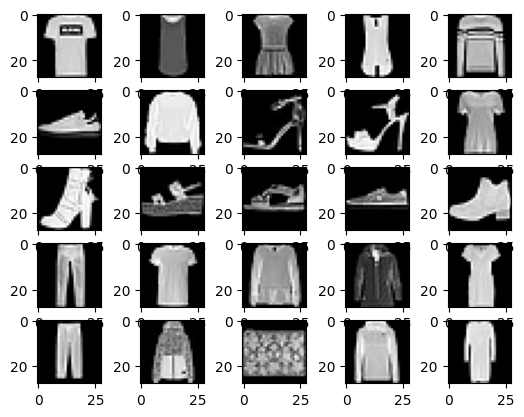

In [ ]:
import matplotlib.pyplot as plt
for i in range(1,26):
  plt.subplot(5,5,i)
  plt.imshow(X_train[i],cmap='gray')

## Step 1.3: Setup CLIP enviroment

We will install CLIP and set up our environment to leverage the GPU. Following that, we'll load a ResNet-50 model, `RN50`, from the CLIP models. Do not change the model in this assignemnt but feel free to explore other available models in the package.

In [ ]:
!pip install git+https://github.com/openai/CLIP.git
import clip

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-lg4r0d8s
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-lg4r0d8s
  Resolved https://github.com/openai/CLIP.git to commit a1d071733d7111c9c014f024669f959182114e33
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 1.7 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369500 sha256=0ca2386626982be8edc6cec68fdd250afbcac487084e8a2c365b975a58ff3eb3
  Stored in directory: /tmp/pip-ephem-wheel-cache-nulzwkpa/wheels/da/2b/4c/d6691fa9597aac8bb85d2ac13b112deb897d5b50f5ad9a37e4
Successfully built clip


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load('RN50', device=device)

100%|███████████████████████████████████████| 244M/244M [00:06<00:00, 39.0MiB/s]


##Step 1.4: Encoding Text Labels
Create a list called `label_texts` that consists of string labels for this dataset. You can use either a sentence for each class or simply a single word.

In [ ]:
label_texts=

Tokenize (encode) the `label_texts` using CLIP and store the tokens in a variable named `label_texts_tokens`.

In [ ]:
label_texts_tokens =

In [ ]:
#Executing the following code should print True if you have written your code correctly.
label_texts_tokens.shape==torch.Size([10, 77])

True

#Step 2: Model direct output (No added classifier)

In this section, we will input all the images from the test data into the CLIP model along with the text labels we have created to observe how it predicts the output.

Following the lecture code:

Loop through all images in the test set, `X_test`.
For each image, apply preprocessing and then use the model to extract features. Append these features to the list named `X_test_CLIP_features`.
Compute the logits and then determine the matching probabilities with the texts in `label_texts_tokens`. The highest probability indicates the predicted class. `np.argmax(probabilities)` will provide the index of the label with the highest probability.
Append the predicted label (class) to `y_test_predicted_direct`.

<font color=blue>Do everything in one loop and it should take ~7 minutes to finish.



In [ ]:
y_test_predicted_direct=[]
X_test_CLIP_features=[]
with torch.no_grad():
  for pic in X_test:








In [ ]:
##Executing the following code should print True if you have written your code correctly and have 10000 predicted labels
len(y_test_predicted_direct)==10000

True

In [ ]:
##Executing the following code should print True if you have written your code correctly and have 10000 feature sets
len(X_test_CLIP_features)==10000

True

In [ ]:
##Executing the following code should print True if you have written your code correctly and have 1024 features for each image
X_test_CLIP_features[0].shape==torch.Size([1, 1024])

True

Run the following command to see the prediction result on the test data.

              precision    recall  f1-score   support

           0       0.79      0.48      0.59      1000
           1       0.29      0.99      0.45      1000
           2       0.31      0.74      0.43      1000
           3       0.60      0.36      0.45      1000
           4       0.57      0.19      0.29      1000
           5       0.07      0.00      0.01      1000
           6       0.86      0.01      0.02      1000
           7       0.47      0.97      0.63      1000
           8       1.00      0.31      0.47      1000
           9       0.82      0.20      0.32      1000

    accuracy                           0.43     10000
   macro avg       0.58      0.43      0.37     10000
weighted avg       0.58      0.43      0.37     10000



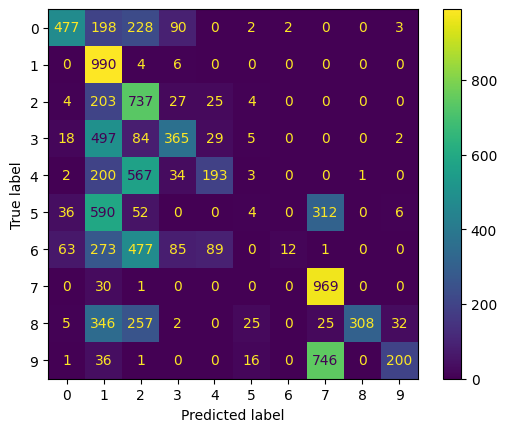

In [ ]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score

print(classification_report(y_test,y_test_predicted_direct))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_test_predicted_direct)).plot()

#Step 3: Extracted Features + Classifier
In this step, we will apply a classifier to the extracted features to evaluate if we can achieve better results.

##Step 3.1: Extracting features for the training data
Run a code similar to what you executed for the test data to extract features for the training data.

Please note that you only need the features, so **do not** calculate the logits and probabilities.

<font color=red>Perform all the steps within a single loop, and it should take approximately 10 minutes to complete.

In [ ]:
X_train_CLIP_features=[]
with torch.no_grad():
  for pic in X_train:





##Step 3.2: Train a linear classifier - Logistic regression.

Choose the classifier parameters in a manner that avoids any warnings; the model **must** converge.`max_iter` should not be more than 100.

In [ ]:
from sklearn.linear_model import LogisticRegression

LGR=LogisticRegression(          )#fill the model paramaeters inside the paranthesis.

#Do not change the line below
LGR.fit(X_train_CLIP_features,y_train)

Predict the labels using the model trained above `LGR` for the testing dataset.

In [ ]:
y_test_predicted_LGR=

Run the following command to see the prediction result on the test data.

              precision    recall  f1-score   support

           0       0.80      0.82      0.81      1000
           1       0.98      0.97      0.97      1000
           2       0.78      0.82      0.80      1000
           3       0.81      0.86      0.83      1000
           4       0.75      0.79      0.77      1000
           5       0.94      0.93      0.93      1000
           6       0.68      0.55      0.61      1000
           7       0.91      0.92      0.92      1000
           8       0.96      0.97      0.96      1000
           9       0.94      0.94      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.85      0.86      0.85     10000
weighted avg       0.85      0.86      0.85     10000



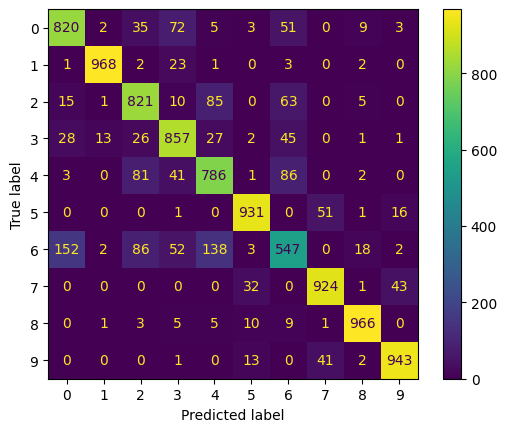

In [ ]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score

print(classification_report(y_test,y_test_predicted_LGR))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_test_predicted_LGR)).plot()

##Step 3.3: Train a non linear classifier - MLP (with hidden layer)

Ensure the inclusion of a hidden layer, `hidden_layer_sizes` in the model parameters to make the classifier non-linear.

Change the parameters until you achieve an **accuracy of 89%** on the test subset.

*   The fewer the number of perceptrons in the hidden layer, the better, as it indicates a model with fewer weights.

*   Setting a smaller value for `max_iter` is preferable, as it means the model will converge faster.

In [ ]:
from sklearn.neural_network import MLPClassifier




MLP=MLPClassifier(   ) #fill the parameter parameters







Predict the labels using the model trained above `MLP` for the testing dataset.

In [ ]:
y_test_predicted_MLP=

Run the following command to see the prediction result on the test data.

              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1000
           1       0.98      0.98      0.98      1000
           2       0.84      0.84      0.84      1000
           3       0.87      0.88      0.87      1000
           4       0.84      0.81      0.83      1000
           5       0.96      0.96      0.96      1000
           6       0.68      0.70      0.69      1000
           7       0.93      0.95      0.94      1000
           8       0.98      0.97      0.97      1000
           9       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



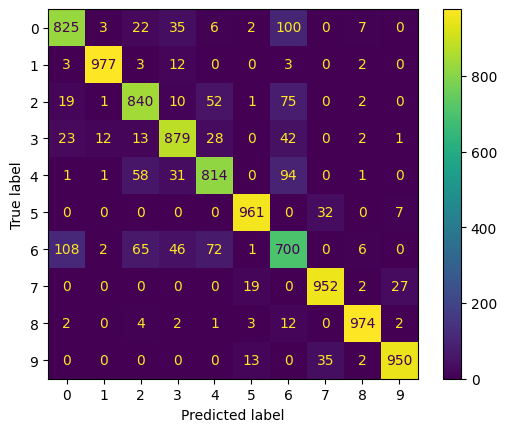

In [ ]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score

print(classification_report(y_test,y_test_predicted_MLP))
ConfusionMatrixDisplay(confusion_matrix(y_test,y_test_predicted_MLP)).plot()

#Step 4: Justification

Please provide your responses to the following questions in the text box below.

1) What was the overall accuracy achieved in the previous assignment (Assignment 10) with the MLP?

2) Why doesn't using the CLIP-RESNET50 model directly produce acceptable results?

3) Why did adding a classifier to CLIP lead to an improvement in results?

4) How did the inclusion of a hidden layer in the MLP contribute to the improvement in results?